## Домашнее задание. Генеративные модели. 

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Два раза за семестр студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим? 

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

## Warning: домашнее задание несколько муторное, потому что требуется обучить 4 типа моделей. Но в то же время оно простое, поэтому проблем с написанием кода возникнуть не должно.

# Введение

## MAGIC – Major Atmospheric Gamma Imaging Cherenkov Telescope

MAGIC (Major Atmospheric Gamma Imaging Cherenkov) - это система, состоящая из двух черенковских телескопов диаметром 17 м. Они предназначены для наблюдения гамма-лучей от галактических и внегалактических источников в диапазоне очень высоких энергий (от 30 ГэВ до 100 ТэВ). 

Телескопами MAGIC в настоящее время управляют около 165 астрофизиков из 24 организаций и консорциумов из 12 стран. MAGIC позволил открыть и исследовать новые классы источников гамма-излучения, таких как, например, пульсары и гамма-всплески (GRB).

<center><img src="img/magic1.jpg" width="1000"></center>

Источник: https://magic.mpp.mpg.de/

Youtube video: https://youtu.be/mjcDSR2vSU8

## Частицы из космоса

Космические частицы, $\gamma$-кванты (фотоны) и адроны (протоны), взаимодействуют с атмосферой и порождают ливни вторичных частиц. Двигаясь с околосветовой скоростью, эти частицы излучают Черенковское излучение. Телескопы фотографируют это излучение. По фотографиям можно определить тип частицы из космоса: фотон или протон.

<center><img src="img/shower.jpg" width="500"></center>

## Фотографии

Задача атмосферного черенковского телескопа - получить изображение ливня путем измерения черенковского света от частиц ливня. Это изображение представляет собой геометрическую проекцию ливня на детектор. Для анализа этих изображений были введены параметры изображения или так называемые параметры Хилласа. Есть два вида параметров изображения: параметры формы и параметры ориентации. (Источник: http://ihp-lx.ethz.ch/Stamet/magic/parameters.html)

<center><img src="img/geo.jpg" width="400"></center>

## Фотоны vs адронов

Изображения для $\gamma$-квантов (фотонов) и адронов (протонов) отличаются по форме кластеров. Астрономы используют модели машинного обучения для классификации этих изображений. Для обучения моделей ученые искусственно генерируют такие изображения для каждого типа частиц с помощью сложных физических симуляторов.


<center><img src="img/gamma_p.png" width="600"></center>

## Ускорение симуляции

Сложные физические симуляторы требуют больших вычислительных ресурсов. Они моделируют прилет частиц из космоса, их взаимодействие с атмосферой, рождение ливней, черенковского излучения и работы телескопов для получения изображений. Но мы можем использовать генеративно-состязательные сети для быстрой симуляции!

In [ ]:
!pip install diffusers

In [53]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
from diffusers import DDPMScheduler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset

# Данные

Будем использовать данные телескопа MAGIC из UCI репозитория https://archive.ics.uci.edu/ml/datasets/MAGIC+Gamma+Telescope. Каждый объект в данных - параметры одного изображения кластера и метка этого кластера (фотон или адрон):


0. Length: major axis of ellipse [mm]
1. Width: minor axis of ellipse [mm]
2. Size: 10-log of sum of content of all pixels [in #phot]
3. Conc: ratio of sum of two highest pixels over fSize [ratio]
4. Conc1: ratio of highest pixel over fSize [ratio]
5. Asym: distance from highest pixel to center, projected onto major axis [mm]
6. M3Long: 3rd root of third moment along major axis [mm]
7. M3Trans: 3rd root of third moment along minor axis [mm]
8. Alpha: angle of major axis with vector to origin [deg]
9. Dist: distance from origin to center of ellipse [mm]
10. class: g,h # gamma (signal), hadron (background)

In [54]:
# read data
names = np.array(
    [
        "Length",
        "Width",
        "Size",
        "Conc",
        "Conc1",
        "Asym",
        "M3Long",
        "M3Trans",
        "Alpha",
        "Dist",
        "class",
    ]
)
data = pd.read_csv("magic04.data", header=None)
data.columns = names
data.head()

,Length,Width,Size,Conc,Conc1,Asym,M3Long,M3Trans,Alpha,Dist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


# Постановка задачи

Ваша задача заключается в том, чтобы с помощью генеративно-состязательных сетей научится генерировать параметры кластеров на изображениях телекопа для каждого типа частиц (фотона или адрона):

- $X$ - матрица реальных объектов, которые нужно начиться генерировать;
- $y$ - метки классов, которые будем использовать как условие при генерации.

In [55]:
# параметры кластеров на изображениях
X = data[names[:-1]].values
X = np.abs(X)

# метки классов
labels = data[names[-1]].values
y = np.ones((len(labels), 1))
y[labels == "h"] = 0

In [56]:
# примеры
X[:2]

array([[2.87967e+01, 1.60021e+01, 2.64490e+00, 3.91800e-01, 1.98200e-01,
        2.77004e+01, 2.20110e+01, 8.20270e+00, 4.00920e+01, 8.18828e+01],
       [3.16036e+01, 1.17235e+01, 2.51850e+00, 5.30300e-01, 3.77300e-01,
        2.62722e+01, 2.38238e+01, 9.95740e+00, 6.36090e+00, 2.05261e+02]])

In [57]:
# примеры
y[:10]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

# Визуализация данных

Каждое изображение описывается 10 параметрами. Давайте построим распределения значений каждого параметра для каждого типа частиц.

In [58]:
def plot_hists(X1, X2, names, label1, label2, bins=np.linspace(-3, 3, 61)):
    plt.figure(figsize=(4 * 4, 4 * 2))
    for i in range(X1.shape[1]):
        plt.subplot(3, 4, i + 1)
        plt.hist(X1[:, i], bins=bins, alpha=0.5, label=label1, color="C0")
        plt.hist(X2[:, i], bins=bins, alpha=0.5, label=label2, color="C1")
        plt.xlabel(names[i], size=14)
        plt.legend(loc="best")
    plt.tight_layout()

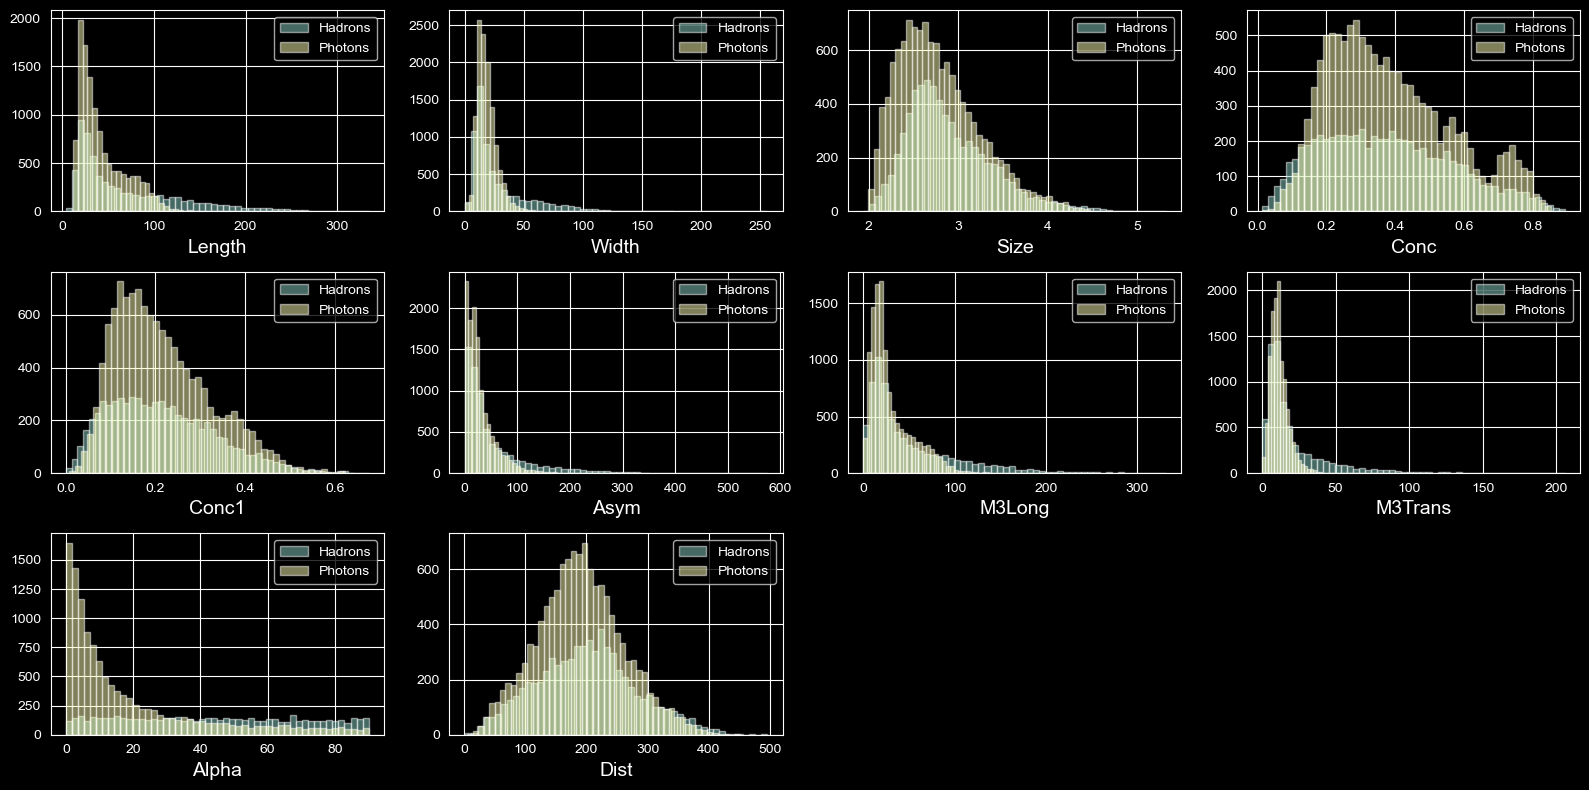

In [59]:
plot_hists(
    X[y[:, 0] == 0], X[y[:, 0] == 1], names, label1="Hadrons", label2="Photons", bins=50
)

# Предобработка данных

Из графика видим, что распределения для многих признаков имеют тяжелые хвосты. Это делает обучение генеративных моделей тяжелее. Поэтому, нужно как-то преобразовать данные, чтобы убрать эти тяжелые хвосты. 

## Задание 1 (0.5 балла)

Используя функцию `sklearn.preprocessing.QuantileTransformer` трансформируйте входные данные `X`. Это преобразование делает так, чтобы распределение каждого параметра было нормальным. Описание функции доступно по ссылке http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html. Используйте значение параметра `output_distribution='normal'`. 

In [60]:
### YOUR CODE IS HERE ######
from sklearn.preprocessing import QuantileTransformer
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_qt = qt.fit_transform(X)
### THE END OF YOUR CODE ###

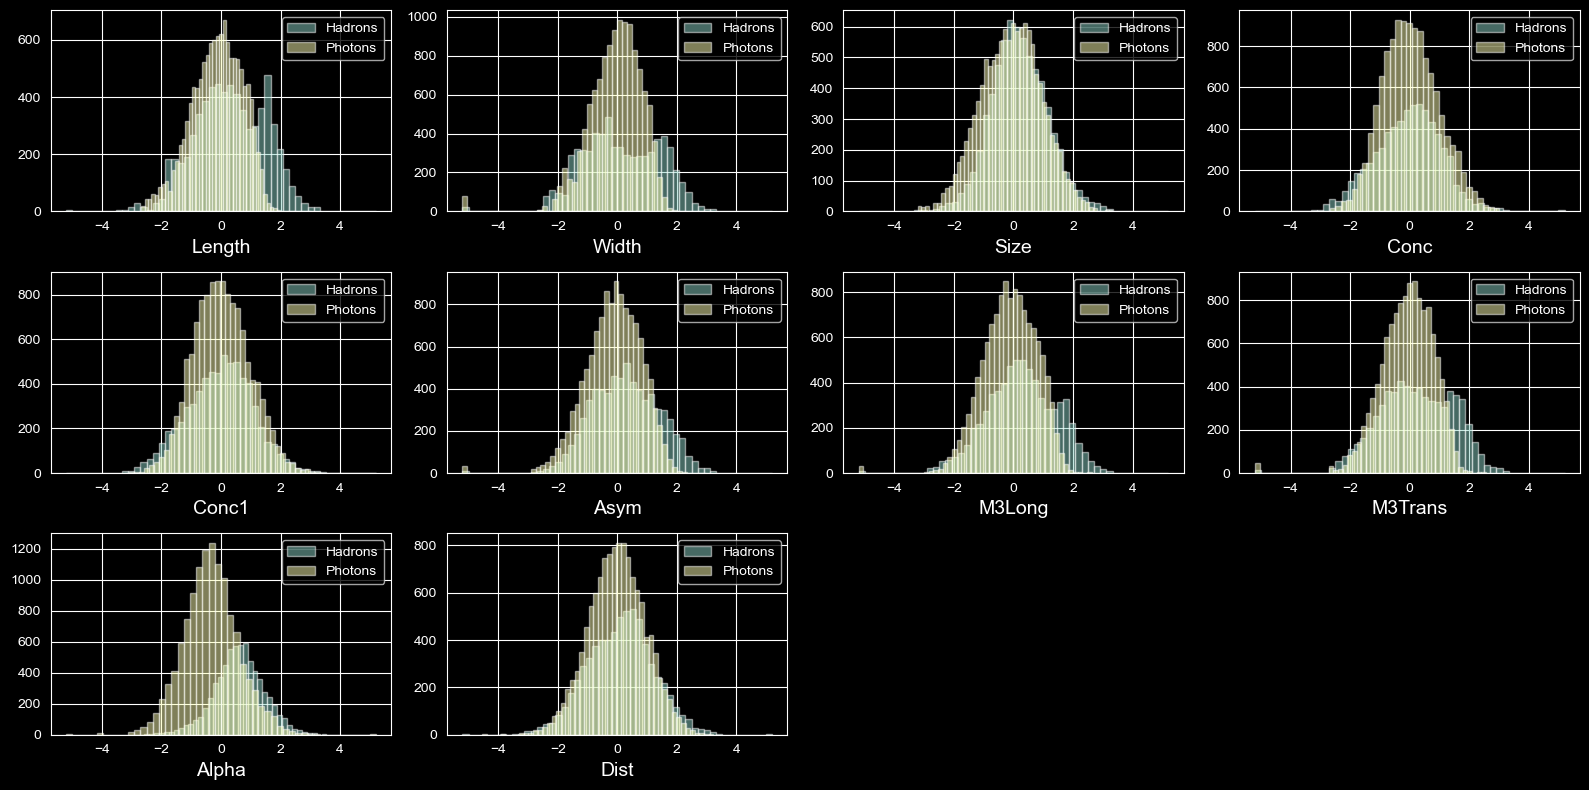

In [61]:
plot_hists(
    X_qt[y[:, 0] == 0],
    X_qt[y[:, 0] == 1],
    names,
    label1="Hadrons",
    label2="Photons",
    bins=50,
)

# Обучающая и тестовая выборки

In [62]:
# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_qt, y, stratify=y, test_size=0.5, shuffle=True, random_state=11
)

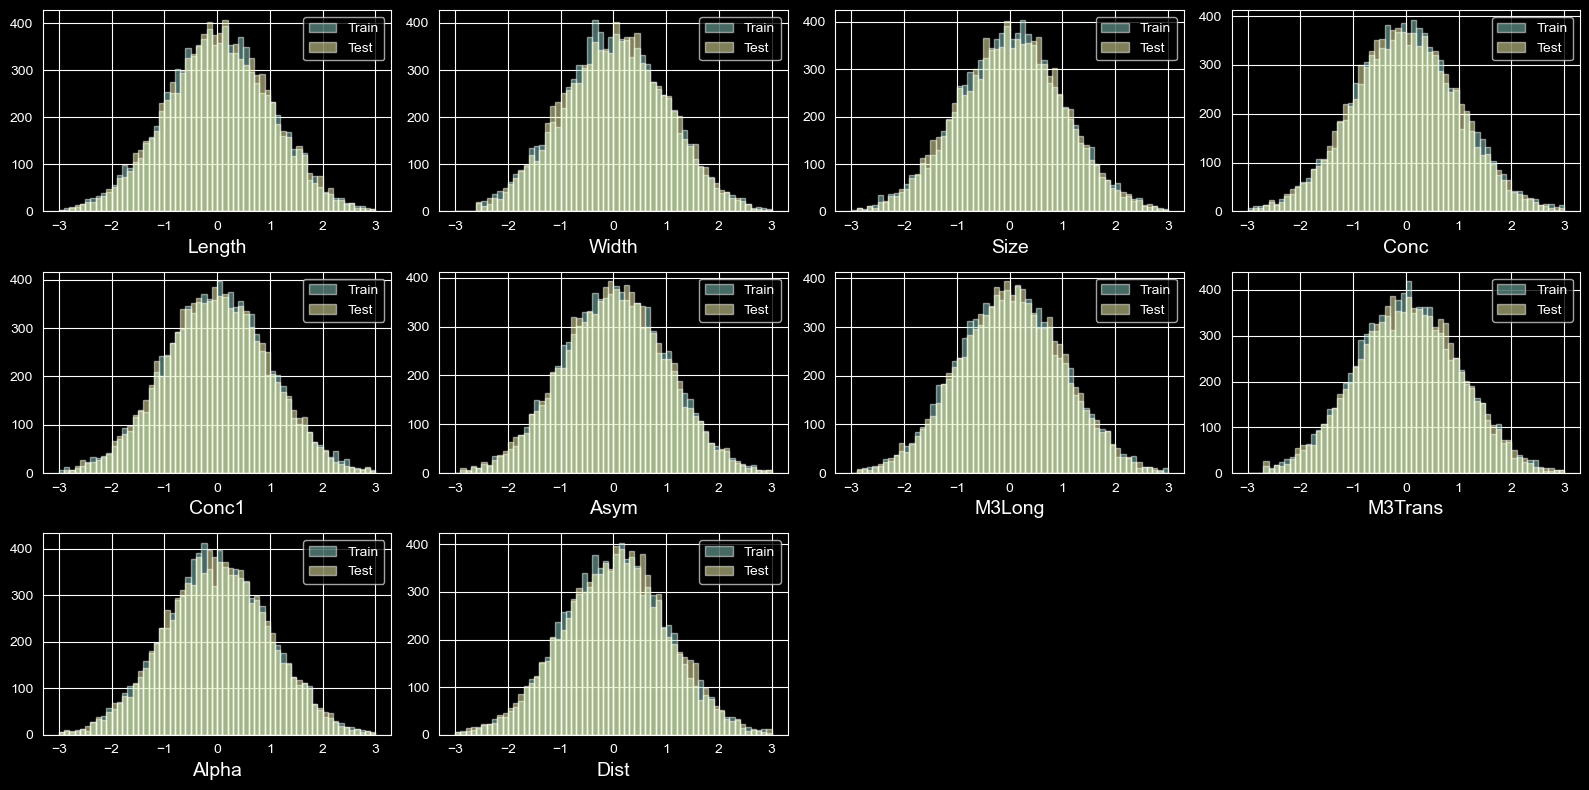

In [63]:
plot_hists(X_train, X_test, names, label1="Train", label2="Test")

# Conditional WGAN

Мы будем использовать `Conditional WGAN`, который изображен на рисунке. В качестве условия `y` мы будем использовать метку класса: **0** - адрон, **1** - фотон. Таким образом, мы будем сообщать генератору для какой частицы нужно генерировать параметры изображения. 

<center><img src="img/cgan.png" width="800"></center>

Генератор $\hat{x} = G(z, y)$ будет принимать на вход шумовой вектор $z$ и вектор условий $y$, а выдавать будет сгенерированный (фейковый) вектор параметров $\hat{x}$. 

Дискриминатор $D(x, y)$ будет принимать на вход вектор параметров $x$ и вектор условий $y$, а возвращать будет рациональное число.

Обучать `Conditional WGAN` будем с такой функцией потерь:

$$L(G, D) = -\frac{1}{n} \sum_{x_i \in X, y_i \in y} D(x_i, y_i) + \frac{1}{n} \sum_{z_i \in Z, y_i \in y} D(G(z_i, y_i), y_i) \to \max_G \min_D$$

In [64]:
DEVICE = torch.device("mps")

In [65]:
DEVICE

device(type='mps')

## Задание 2 (0.25 балла)

Реализуйте нейронную сеть для генератора со следующими слоями:
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Выходной слой.

Подсказка: используйте функцию `nn.Sequential()`.

In [66]:
class Generator(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()

        ### YOUR CODE IS HERE ######
        self.net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, n_outputs)
        )
        ### THE END OF YOUR CODE ###

    def forward(self, z, y):
        zy = torch.cat((z, y), dim=1)
        return self.net(zy)

## Задание 3 (0.25 балла)

Реализуйте нейронную сеть для дискриминатора со следующими слоями:
- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Выходной слой.

Подсказка: используйте функцию `nn.Sequential()`.

In [67]:
class Discriminator(nn.Module):
    def __init__(self, n_inputs):
        super().__init__()

        ### YOUR CODE IS HERE ######
        self.net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 1)
        )
        ### THE END OF YOUR CODE ###

    def forward(self, x, y):
        xy = torch.cat((x, y), dim=1)
        return self.net(xy)

## Задание 4 (1 балл)

Реализуйте класс для обучения генеративной модели.

- Подсказка 1: не забывайте ограничивать веса дискриминатора. Для этого используйте `p.data.clamp_(-0.01, 0.01)`, где `p` веса дискриминатора.
- Подсказка 2: `n_critic` - число итераций обучения дискриминатора на одну итерацию обучения генератора.
- Подсказка 3: Используйте `X_tensor = torch.tensor(X_numpy, dtype=torch.float, device=DEVICE)` для перевода numpy в тензор.

In [68]:
class Fitter(object):
    def __init__(
        self,
        generator,
        discriminator,
        batch_size=32,
        n_epochs=10,
        latent_dim=1,
        lr=0.0001,
        n_critic=5,
    ):

        self.generator = generator
        self.discriminator = discriminator
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.n_critic = n_critic

        self.opt_gen = torch.optim.RMSprop(self.generator.parameters(), lr=self.lr)
        self.opt_disc = torch.optim.RMSprop(self.discriminator.parameters(), lr=self.lr)

        self.generator.to(DEVICE)
        self.discriminator.to(DEVICE)

    def fit(self, X, y):

        # numpy to tensor
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # tensor to dataset
        dataset_real = TensorDataset(X_real, y_cond)

        # Turn on training
        self.generator.train(True)
        self.discriminator.train(True)

        self.loss_history = []

        # Fit GAN
        for epoch in range(self.n_epochs):
            for i, (real_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):

                ### YOUR CODE IS HERE ######

                curr_batch_size = real_batch.shape[0]  # текущий размер батча
                z = torch.normal(0, 1, (curr_batch_size, self.latent_dim), device=DEVICE)  # генерируем вектор шума
                fake_batch = self.generator(z, cond_batch).detach()  # генерируем фейковые данные (отключаем градиенты для генератора при обучении D)

                # Обучение Дискриминатора

                self.opt_disc.zero_grad()

                # Оценки дискриминатора
                D_real = self.discriminator(real_batch, cond_batch)
                D_fake = self.discriminator(fake_batch, cond_batch)

                # Loss дискриминатора (WGAN loss)
                loss_D = -torch.mean(D_real) + torch.mean(D_fake)

                loss_D.backward()
                self.opt_disc.step()

                # Клиппинг весов дискриминатора
                for p in self.discriminator.parameters():
                    p.data.clamp_(-0.01, 0.01)

                # Обучение Генератора (каждые n_critic шагов)

                if i % self.n_critic == 0:
                    self.opt_gen.zero_grad()

                    # Генерируем новые фейковые данные (уже с включенными градиентами G)
                    z_gen = torch.normal(0, 1, (curr_batch_size, self.latent_dim), device=DEVICE)
                    fake_batch_gen = self.generator(z_gen, cond_batch)

                    D_fake_gen = self.discriminator(fake_batch_gen, cond_batch)

                    # Loss генератора
                    loss_G = -torch.mean(D_fake_gen)

                    loss_G.backward()
                    self.opt_gen.step()

                ### THE END OF YOUR CODE ###

            # caiculate and store loss after an epoch
            Z_noise = torch.normal(0, 1, (len(X_real), self.latent_dim), device=DEVICE)
            X_fake = self.generator(Z_noise, y_cond)
            loss_epoch = torch.mean(self.discriminator(X_real, y_cond)) - torch.mean(
                self.discriminator(X_fake, y_cond)
            )
            self.loss_history.append(loss_epoch.detach().cpu())

        # Turn off training
        self.generator.train(False)
        self.discriminator.train(False)

## Обучение
Обучим модель на данных.

In [69]:
%%time
latent_dim = 10
generator = Generator(n_inputs=latent_dim + y.shape[1], n_outputs=X_train.shape[1])
discriminator = Discriminator(n_inputs=X_train.shape[1] + y.shape[1])

fitter = Fitter(
    generator,
    discriminator,
    batch_size=50,
    n_epochs=100,
    latent_dim=latent_dim,
    lr=0.0001,
    n_critic=5,
)
fitter.fit(X_train, y_train)

CPU times: user 28.8 s, sys: 1.81 s, total: 30.6 s
Wall time: 29.5 s


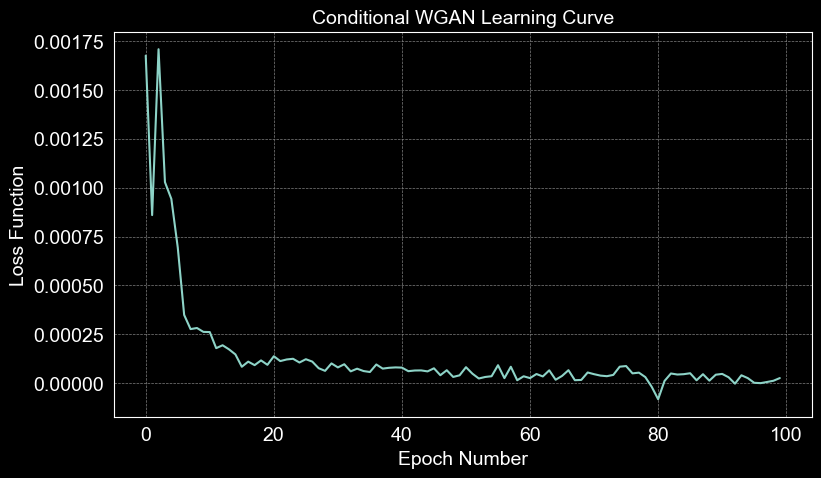

In [70]:
# WGAN learning curve
plt.figure(figsize=(9, 5))
plt.plot(fitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional WGAN Learning Curve", size=14)
plt.grid(visible=True, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

## Задание 5 (0.5 балла)

Реализуйте функцию для генерации новый объектов $X$ по вектору условий $y$.

In [71]:
def generate(generator, y, latent_dim):
    ### YOUR CODE IS HERE ######
    # Переводим модель в режим инференса (важно для BatchNorm)
    generator.eval()

    with torch.no_grad():
        # Переводим вектор условий y в тензор
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # Генерируем случайный шум из нормального распределения
        z = torch.normal(0, 1, (len(y), latent_dim), device=DEVICE)

        # Генерируем фейковые данные
        X_fake_tensor = generator(z, y_cond)

        # Переводим тензор обратно на CPU и конвертируем в NumPy
        X_fake = X_fake_tensor.cpu().numpy()
    ### THE END OF YOUR CODE ###
    return X_fake  # numpy

Теперь сгенерируем фейковые матрицы `X_fake_train` и `X_fake_test`. Сравним их с матрицами реальных объектов `X_train` и `X_test`

In [72]:
X_fake_train = generate(fitter.generator, y_train, latent_dim)

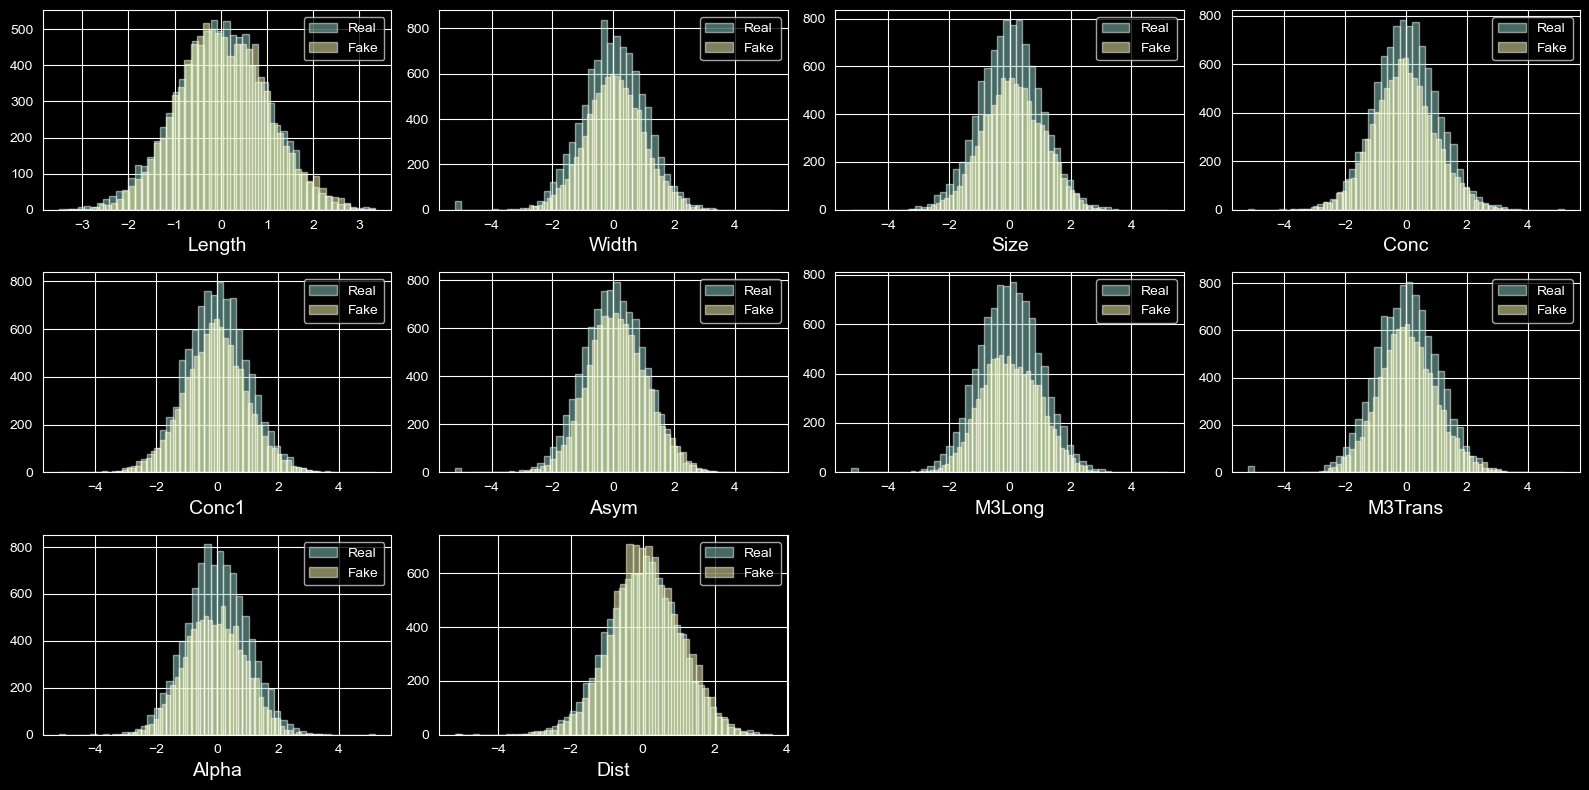

In [73]:
plot_hists(X_train, X_fake_train, names, label1="Real", label2="Fake", bins=50)

In [74]:
X_fake_test = generate(fitter.generator, y_test, latent_dim)

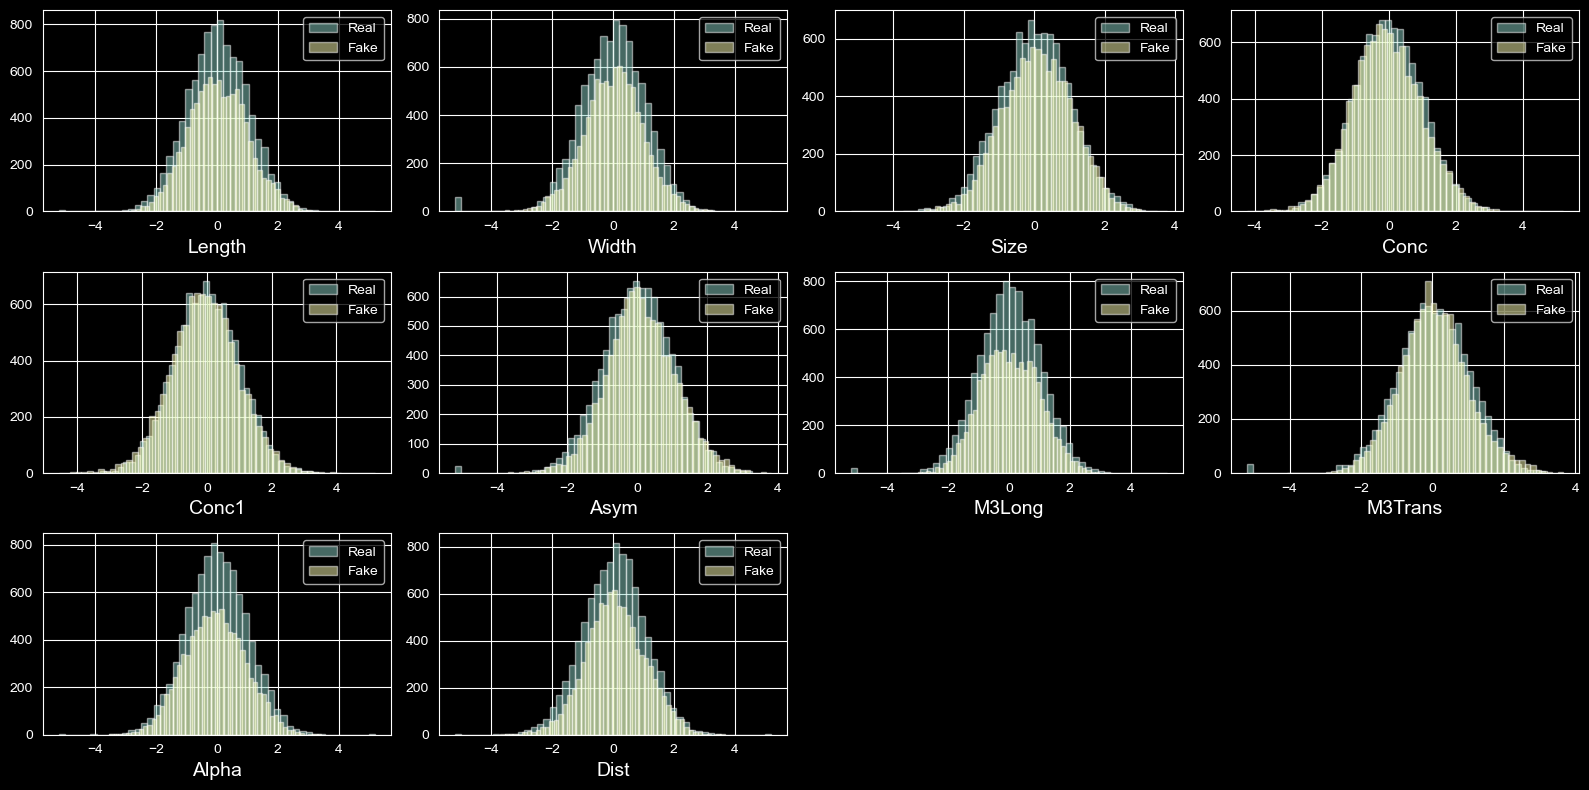

In [75]:
plot_hists(X_test, X_fake_test, names, label1="Real", label2="Fake", bins=50)

# Измерение качества генерации

<center><img src="img/clf.png" width="600"></center>

Измерим сходство распределений внешним (подумайте почему) классификатором.

In [76]:
# собираем реальную и фейковую матрицы в одну
XX_train = np.concatenate((X_fake_train, X_train), axis=0)
XX_test = np.concatenate((X_fake_test, X_test), axis=0)

yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test))

In [77]:
# обучаем классификатор
clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)

# получаем прогнозы
yy_test_proba = clf.predict_proba(XX_test)[:, 1]

In [78]:
auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC = ", auc)

ROC AUC =  0.6908252589282852


# Условные вариационные автокодировщики

<center><img src="img/cvae.svg" width="600"></center>

Теперь, решим эту же задачу используя условный автокодировщик (CVAE).

## Задание 6 (0.5 балла)

Реализуйте нейронную сеть для энкодера со следующими слоями:
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Выходной слой для mu; Выходной слой для log_sigma;

Подсказка: используйте функцию `nn.Sequential()`.

In [79]:
class Encoder(nn.Module):
    def __init__(self, n_inputs, lat_size):
        super().__init__()

        ### YOUR CODE IS HERE ######

        # Общая часть сети для извлечения признаков
        self.enc_net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.BatchNorm1d(100),
            nn.ReLU()
        )

        # Выходной слой для математического ожидания (mu)
        self.mu = nn.Linear(100, lat_size)

        # Выходной слой для логарифма дисперсии (log_sigma)
        self.log_sigma = nn.Linear(100, lat_size)

        ### THE END OF YOUR CODE ###

    def forward(self, x, y):
        z = torch.cat((x, y), dim=1)
        z = self.enc_net(z)
        mu = self.mu(z)
        log_sigma = self.log_sigma(z)
        return mu, log_sigma

## Задание 7 (0.5 балла)

Реализуйте нейронную сеть для декодера со следующими слоями:
- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Выходной слой.

Подсказка: используйте функцию `nn.Sequential()`.

In [80]:
class Decoder(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()

        ### YOUR CODE IS HERE ######
        self.dec_net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, n_outputs)
        )
        ### THE END OF YOUR CODE ###

    def forward(self, z, y):
        z_cond = torch.cat((z, y), dim=1)
        x_rec = self.dec_net(z_cond)
        return x_rec

## Задание 8 (0.5 балл)

Реализуйте класс для обучения вариационного автокодировщика.

In [81]:
class VAEFitter:
    def __init__(
        self,
        encoder,
        decoder,
        batch_size=32,
        n_epochs=10,
        latent_dim=1,
        lr=0.0001,
        KL_weight=0.001,
    ):

        self.encoder = encoder
        self.decoder = decoder
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.KL_weight = KL_weight

        self.criterion = nn.MSELoss()
        self.opt = torch.optim.RMSprop(
            list(self.encoder.parameters()) + list(self.decoder.parameters()),
            lr=self.lr,
        )

        self.encoder.to(DEVICE)
        self.decoder.to(DEVICE)

    def sample_z(self, mu, log_sigma):
        eps = torch.randn(mu.shape).to(DEVICE)
        return mu + torch.exp(log_sigma / 2) * eps

    def custom_loss(self, x, rec_x, mu, log_sigma):
        KL = torch.mean(
            -0.5 * torch.sum(1 + log_sigma - mu**2 - log_sigma.exp(), dim=1), dim=0
        )
        recon_loss = self.criterion(x, rec_x)
        return KL * self.KL_weight + recon_loss

    def compute_loss(self, x_batch, cond_batch):

        ### YOUR CODE IS HERE ######

        # Пропускаем реальные данные и условия через энкодер
        mu, log_sigma = self.encoder(x_batch, cond_batch)

        # Сэмплируем латентный вектор z
        z = self.sample_z(mu, log_sigma)

        # Генерируем восстановленные данные через декодер
        rec_x = self.decoder(z, cond_batch)

        # Считаем функцию потерь (Reconstruction Loss + KL Divergence)
        loss = self.custom_loss(x_batch, rec_x, mu, log_sigma)

        ### THE END OF YOUR CODE ###

        return loss

    def fit(self, X, y):

        # numpy to tensor
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # tensor to dataset
        dataset_real = TensorDataset(X_real, y_cond)

        # Turn on training
        self.encoder.train(True)
        self.decoder.train(True)

        self.loss_history = []

        # Fit GAN
        for epoch in range(self.n_epochs):
            for i, (x_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):

                # caiculate loss
                loss = self.compute_loss(x_batch, cond_batch)

                # optimization step
                self.opt.zero_grad()
                loss.backward()
                self.opt.step()

            # caiculate and store loss after an epoch
            loss_epoch = self.compute_loss(X_real, y_cond)
            self.loss_history.append(loss_epoch.detach().cpu())

        # Turn off training
        self.encoder.train(False)
        self.decoder.train(False)

## Обучение
Обучим модель на данных.

In [82]:
%%time

latent_dim = 10

encoder = Encoder(n_inputs=X_train.shape[1] + y.shape[1], lat_size=latent_dim)
decoder = Decoder(n_inputs=latent_dim + y.shape[1], n_outputs=X_train.shape[1])

vae_fitter = VAEFitter(
    encoder,
    decoder,
    batch_size=50,
    n_epochs=100,
    latent_dim=latent_dim,
    lr=0.001,
    KL_weight=0.001,
)
vae_fitter.fit(X_train, y_train)

CPU times: user 39.3 s, sys: 3.14 s, total: 42.4 s
Wall time: 59.4 s


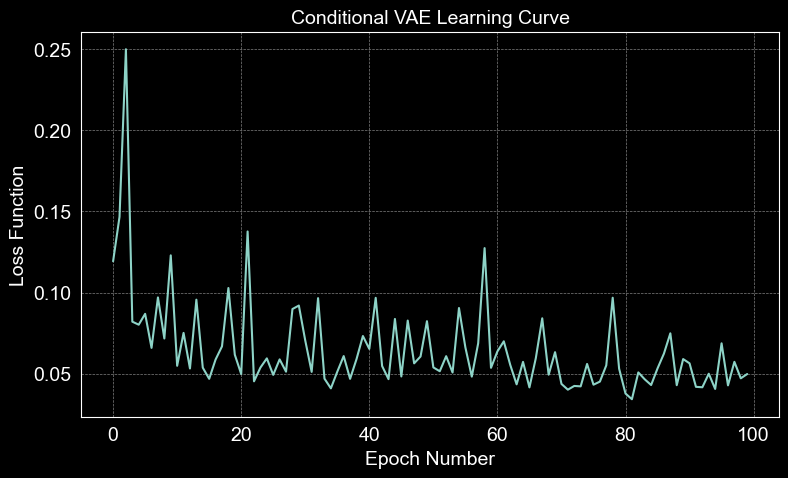

In [83]:
# WGAN learning curve
plt.figure(figsize=(9, 5))
plt.plot(vae_fitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional VAE Learning Curve", size=14)
plt.grid(visible=True, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

## Задание 9 (0.5 балл)

Реализуйте функцию для генерации новый объектов $X$ по вектору условий $y$.

In [84]:
def generate(decoder, y, latent_dim):
    ### YOUR CODE IS HERE ######

    # Переводим декодер в режим инференса
    decoder.eval()

    with torch.no_grad():
        # Переводим вектор условий y в тензор
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # Сэмплируем латентный вектор z из стандартного нормального распределения
        z = torch.normal(0, 1, (len(y), latent_dim), device=DEVICE)

        # Генерируем фейковые данные с помощью декодера
        X_fake_tensor = decoder(z, y_cond)

        # Переводим тензор обратно на CPU и конвертируем в NumPy
        X_fake = X_fake_tensor.cpu().numpy()
    ### THE END OF YOUR CODE ###
    return X_fake  # numpy

Теперь сгенерируем фейковые матрицы `X_fake_train` и `X_fake_test`. Сравним их с матрицами реальных объектов `X_train` и `X_test`

In [85]:
X_fake_train = generate(vae_fitter.decoder, y_train, latent_dim)

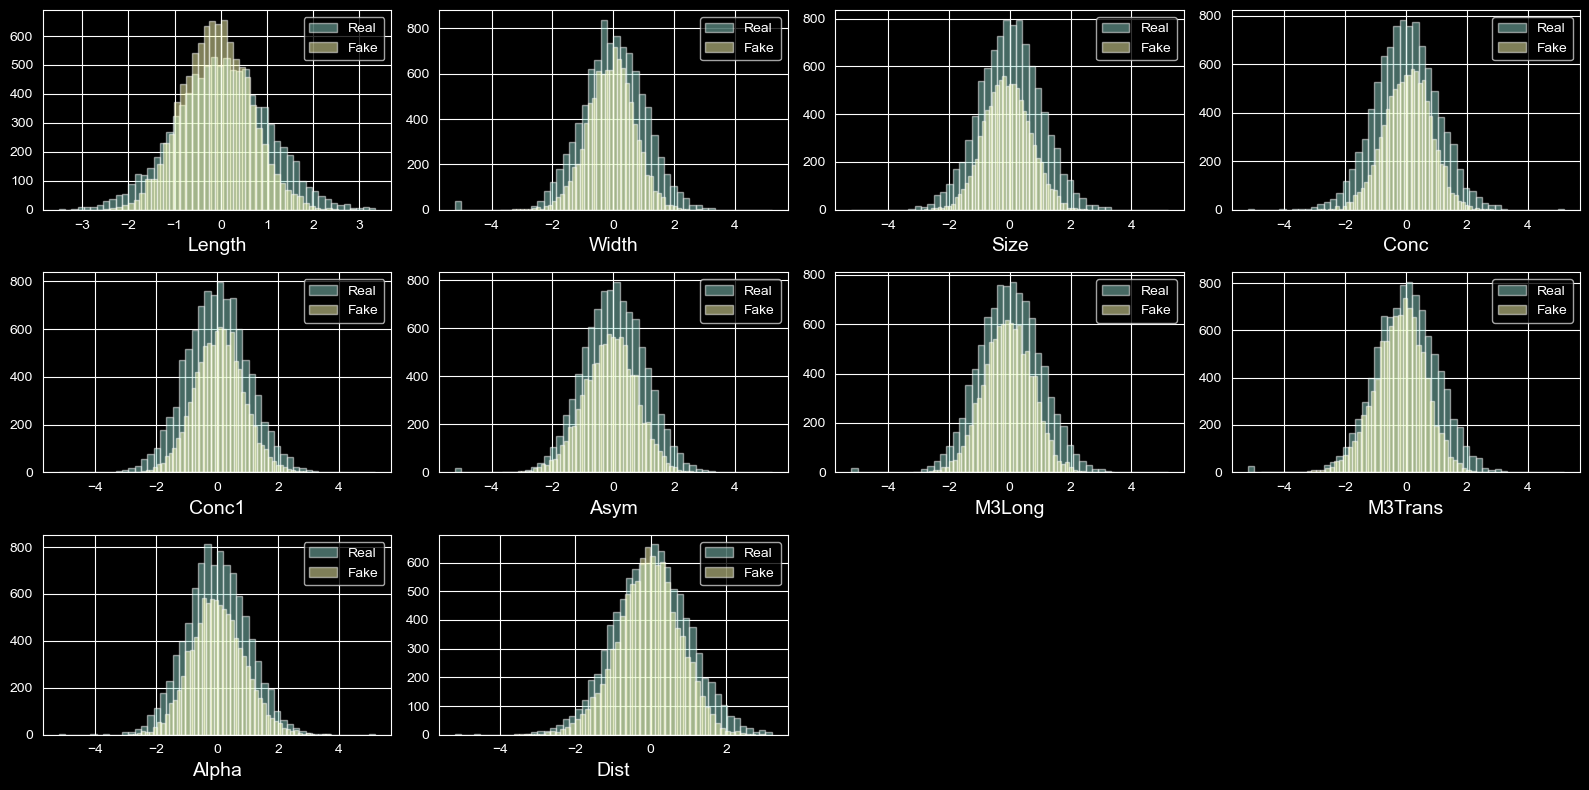

In [86]:
plot_hists(X_train, X_fake_train, names, label1="Real", label2="Fake", bins=50)

In [87]:
X_fake_test = generate(vae_fitter.decoder, y_test, latent_dim)

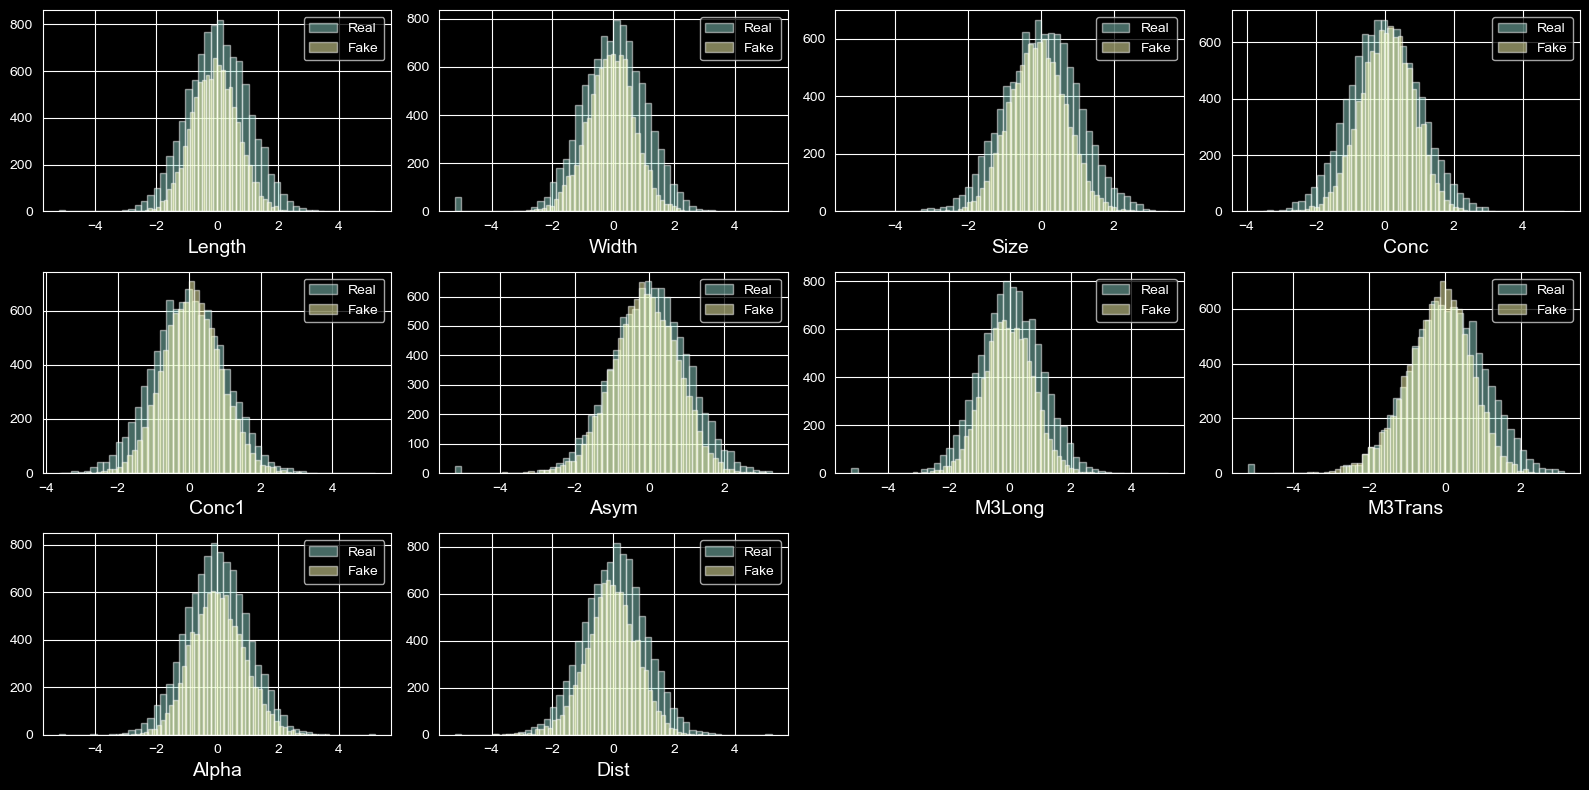

In [88]:
plot_hists(X_test, X_fake_test, names, label1="Real", label2="Fake", bins=50)

# Измерение качества генерации

Измерим сходство распределений классификатором.

In [89]:
# собираем реальную и фейковую матрицы в одну
XX_train = np.concatenate((X_fake_train, X_train), axis=0)
XX_test = np.concatenate((X_fake_test, X_test), axis=0)

yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test))

In [90]:
# обучаем классификатор
clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)

# получаем прогнозы
yy_test_proba = clf.predict_proba(XX_test)[:, 1]

In [91]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC = ", auc)

ROC AUC =  0.7015033707393069


# Диффузионные модели 

Все то же самое, что и выше, но теперь диффузионки

In [92]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("mps")

## Задание 10 (0.5 балла)

Реализуйте фукнцию для зашумления данных, адаптировав ее под наш тип данных.

In [93]:
def corrupt(x, amount):
    ### YOUR CODE IS HERE ######

    # Генерируем шум такой же размерности, как входной тензор x
    noise = torch.randn_like(x)

    # Смешиваем чистые данные с шумом
    x = x * (1 - amount) + noise * amount

    ### THE END OF YOUR CODE ###
    return x

Совет: прочтите доку на шедулер, то как он объявлен ниже может быть неоптимально для наших данных (потому что у нас не картинки!) :)

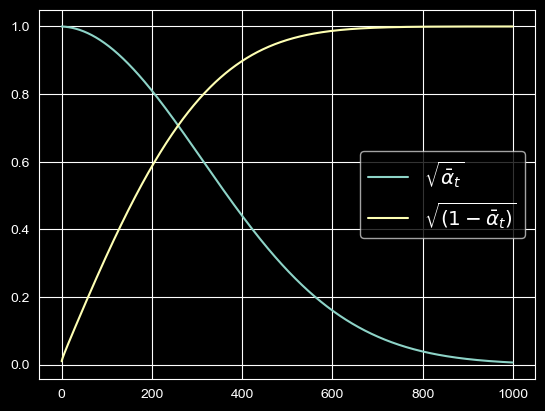

In [94]:
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
plt.plot(
    noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$"
)
plt.plot(
    (1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5,
    label=r"$\sqrt{(1 - \bar{\alpha}_t)}$",
)
plt.legend(fontsize="x-large")

## Задание 11 (0.5 балла)

Реализуйте нейронную сеть. В качетсве архитектуры можете взять модель генератора. В процессе экспериментов попробуйте изменять архитектуру модели для улучшения качества сгенерированных объектов.

- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Выходной слой.

In [95]:
class DiffusionGenerator(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()

        ### YOUR CODE IS HERE ######
        self.net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, n_outputs)
        )
        ### THE END OF YOUR CODE ###

    def forward(self, z, y):
        # Конкатенируем зашумленный вектор z и вектор условий y
        zy = torch.cat((z, y), dim=1)
        return self.net(zy)

## Задание 12 (0.5 балла)

Напишите функцию для генерации нового объекта с помощью обученной модели.

In [101]:
def generate_with_diffusion(model, y, latent_dim, scheduler):
    ### YOUR CODE IS HERE ######

    # Переводим модель в режим оценки
    model.eval()

    with torch.no_grad():
        # Готовим вектор условий и переносим на девайс
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # Начинаем с чистого гауссовского шума x_T
        sample = torch.randn((len(y), latent_dim), device=DEVICE)

        # Итеративный процесс обратной диффузии

        for t in scheduler.timesteps:  # scheduler.timesteps содержит последовательность шагов от T до 0

            # Предсказываем шум (или обновленное состояние) с помощью модели
            model_output = model(sample, y_cond)

            # Используем scheduler, чтобы сделать шаг назад (от x_t к x_{t-1})
            sample = scheduler.step(model_output, t, sample).prev_sample

        # Переводим результат в numpy
        X_fake = sample.cpu().numpy()

    ### THE END OF YOUR CODE ###
    return X_fake  # numpy

## Задание 13 (1 балла)

Напишите класс обучения диффузионной модели и обучите модель, после чего опишите полученные результаты. Вы можете изменять некоторые части кода для вашего удобства, но оставляйте в таком случаи комментарии, пожалуйста.

In [102]:
import torch.nn.functional as F

class DiffusionFitter:
    def __init__(
        self,
        model,
        batch_size=32,
        n_epochs=10,
        latent_dim=1,
        lr=0.0001,
        n_critic=5,
    ):

        self.model = model
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.n_critic = n_critic

        self.opt_gen = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        self.model.to(DEVICE)

    def fit(self, X, y):
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        dataset_real = TensorDataset(X_real, y_cond)
        self.model.train(True)
        self.loss_history = []

        for epoch in range(self.n_epochs):
            total_loss = 0
            for i, (real_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):
                ### YOUR CODE IS HERE ######
                # Генерируем случайный шум той же формы, что и батч
                noise = torch.randn_like(real_batch)

                # Выбираем случайный временной шаг t для каждого объекта в батче
                timesteps = torch.randint(
                    0, noise_scheduler.config.num_train_timesteps,
                    (real_batch.shape[0],), device=DEVICE
                ).long()

                # Добавляем шум к реальным данным (Forward Diffusion Process)
                noisy_batch = noise_scheduler.add_noise(real_batch, noise, timesteps)

                # Модель предсказывает шум (или исходный сигнал)
                noise_pred = self.model(noisy_batch, cond_batch)

                # Вычисляем MSE loss между истинным шумом и предсказанным
                loss = F.mse_loss(noise_pred, noise)

                # Оптимизация
                self.opt_gen.zero_grad()
                loss.backward()
                self.opt_gen.step()

                total_loss += loss.item()
                ### THE END OF YOUR CODE ###

            # Сохраняем средний лосс за эпоху
            avg_loss = total_loss / (i + 1)
            self.loss_history.append(avg_loss)

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{self.n_epochs}, Loss: {avg_loss:.6f}")

        self.model.train(False)

In [103]:
%%time
latent_dim = 10
model = DiffusionGenerator(n_inputs=latent_dim + y.shape[1], n_outputs=X_train.shape[1])

diffusionFitter = DiffusionFitter(
    model,
    batch_size=50,
    n_epochs=100,
    latent_dim=latent_dim,
    lr=0.0001,
    n_critic=5,
)
diffusionFitter.fit(X_train, y_train)

Epoch 10/100, Loss: 0.288434
Epoch 20/100, Loss: 0.284462
Epoch 30/100, Loss: 0.270691
Epoch 40/100, Loss: 0.273708
Epoch 50/100, Loss: 0.267049
Epoch 60/100, Loss: 0.263122
Epoch 70/100, Loss: 0.265462
Epoch 80/100, Loss: 0.265771
Epoch 90/100, Loss: 0.268814
Epoch 100/100, Loss: 0.266261
CPU times: user 30.1 s, sys: 2.57 s, total: 32.7 s
Wall time: 49.7 s


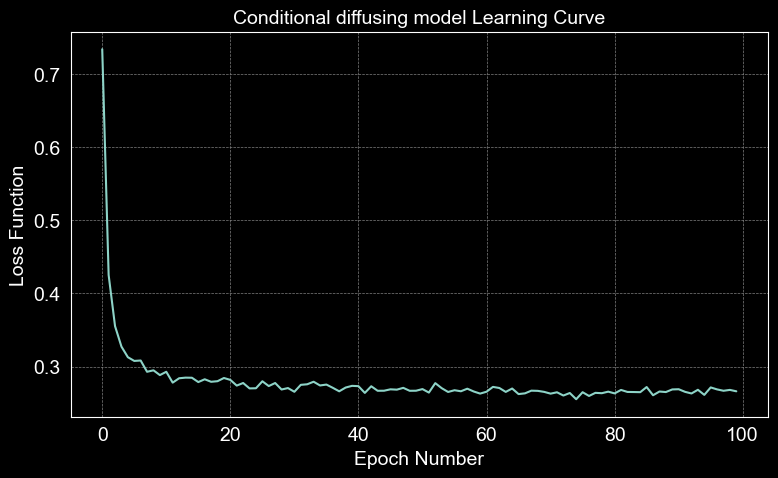

In [104]:
# diffusion learning curve
plt.figure(figsize=(9, 5))
plt.plot(diffusionFitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional diffusing model Learning Curve", size=14)
plt.grid(visible=True, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

## Задание 14 (0.5 балла)
По аналогии с прошлыми экспериментами с GAN моделью сгенерируйте выборку фейковых объектов, равную размеру тестовой выборки, и обучите градиентный бустинг. Обучите модель отличать реальные объекты от фейковых, после чего расчитайте метрику ROC-AUC. Какие получились результаты? Как вы их оцениваете? А в сравнении с сWGAN моделью?

In [105]:
# Генерируем фейковые объекты для тестовой выборки
X_fake_test_diff = generate_with_diffusion(
    diffusionFitter.model,
    y_test,
    latent_dim,
    noise_scheduler
)

# Подготавливаем данные для классификатора (0 - Fake, 1 - Real)
XX_test_diff = np.concatenate((X_fake_test_diff, X_test), axis=0)
yy_test_diff = np.array([0] * len(X_fake_test_diff) + [1] * len(X_test))

# Используем те же обучающие данные для классификатора, что и раньше, но сгенерированные диффузионной моделью на тренировочном y
X_fake_train_diff = generate_with_diffusion(
    diffusionFitter.model,
    y_train,
    latent_dim,
    noise_scheduler
)
XX_train_diff = np.concatenate((X_fake_train_diff, X_train), axis=0)
yy_train_diff = np.array([0] * len(X_fake_train_diff) + [1] * len(X_train))

# Обучаем классификатор
clf_diff = GradientBoostingClassifier()
clf_diff.fit(XX_train_diff, yy_train_diff)

# Получаем прогнозы и считаем ROC-AUC
yy_test_proba_diff = clf_diff.predict_proba(XX_test_diff)[:, 1]
auc_diff = roc_auc_score(yy_test_diff, yy_test_proba_diff)

print("ROC AUC (Diffusion) = ", auc_diff)

ROC AUC (Diffusion) =  0.9661210403349841


### Анализ результатов

#### Какие получились результаты и как я их оцениваю:
- cWGAN: ROC-AUC ~ 0.691
- CVAE: ROC-AUC ~ 0.702
- Диффузионная модель: ROC-AUC ~ 0.966

В методе оценки генеративных моделей с помощью бинарного классификатора идеальным значением ROC-AUC является 0.5.
Это значение означает, что классификатор работает на уровне случайного угадывания,
то есть сгенерированные (фейковые) объекты настолько похожи на реальные, что алгоритм не может их различить.

Исходя из этого, cWGAN и CVAE показали хорошее качество генерации, метрика около 0.7 означает, что распределения сильно пересекаются, хотя и не идеально.
А результат диффузионной модели ROC-AUC = 0.966 является очень плохим, он означает, что градиентный бустинг почти безошибочно отличает сгенерированные данные от реальных.
Модель генерирует распределение, которое визуально или статистически сильно отличается от оригинального датасета.

#### Сравнение с cWGAN и причины такого результата:
Результат может показаться странным, что диффузионная модель, считающаяся более совершенным подходом, проиграла классическому cWGAN, но этому есть объяснение:

- В процессе диффузии шум снимается за 1000 итераций. На каждом шаге t уровень шума разный. Чтобы нейросеть могла корректно предсказать шум, ей необходимо знать текущий шаг t. В нашей простой архитектуре DiffusionGenerator (скопированной у GAN) мы подавали на вход только вектор z и условие y. Сеть не знала, на каком шаге диффузии она находится, и поэтому не смогла выучить корректное преобразование для каждого из 1000 уровней шума.
- cWGAN обучался со специфичным для него расписанием (обучение критика 5 раз на 1 шаг генератора) и клиппингом весов, что стабилизировало его на этих данных. Расписание шума DDPMScheduler (alphas cumprod), используемое нами, по умолчанию оптимизировано для изображений, а не для нормализованных табличных признаков телескопа.

**Вывод:** cWGAN оказался наиболее подходящей и легковесной моделью для данной табличной задачи из коробки. Диффузионная модель обладает большим потенциалом, но требует существенной модификации архитектуры (добавления зависимости от времени t внутри слоев сети), без которой она генерирует легко различимый алгоритмами шум.

# Нормализационные потоки

## Задание 15 (1 балл)

Попробуем обучить RealNVP для решения этой задачи.

**Дополните базовый класс необходимым.**

In [110]:
trainloader = torch.utils.data.DataLoader(X_train, batch_size=64, shuffle=True)

In [112]:
# Main class for NormFlow
class NormalizingFlow(nn.Module):

    def __init__(self, layers, prior):
        super(NormalizingFlow, self).__init__()

        # your code below
        self.layers = nn.ModuleList(layers)
        self.prior = prior

    def log_prob(self, x):
        log_likelihood = None

        for layer in self.layers:
            x, change = layer.f(x)
            if log_likelihood is not None:
                log_likelihood = log_likelihood + change
            else:
                log_likelihood = change

        # Добавляем логарифм вероятности полученного z в базовом (prior) распределении
        log_likelihood = log_likelihood + self.prior.log_prob(x)

        return log_likelihood.mean()

    def sample(self, num_samples):
        # Сэмплируем из простого приорного распределения (латентное пространство)
        x = self.prior.sample((num_samples, ))

        # Проходим через слои в обратном порядке, используя обратные функции g(x)
        # Это переводит шум обратно в распределение данных
        for layer in self.layers[::-1]:
            x = layer.g(x)

        return x

## Задание 16 (1 балл)

Реализуйте нейронную сеть RealNVP. Возьмите для прямого и обратного преобразования нейронную сеть (функцию) со следующими параметрами:

- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Выходной слой.

In [113]:
import torch.nn as nn

class RealNVP(nn.Module):
    def __init__(self, var_size, mask, hidden=100):
        super(RealNVP, self).__init__()
        # self.mask = mask  # вам это может не понадобиться. Воспринимайте как подсказку

        # Регистрируем маску как буфер, чтобы она переносилась на DEVICE вместе с моделью
        self.register_buffer('mask', mask)
        self.var_size = var_size

        # Сеть для сдвига (translation)
        self.nn_t = nn.Sequential(
            nn.Linear(var_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, var_size)
        )

        # Сеть для масштабирования (scale)
        self.nn_s = nn.Sequential(
            nn.Linear(var_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, var_size),
            nn.Tanh() # Tanh используется для стабильности масштабирования
        )

    def f(self, x):
        # x_fixed - часть, которая не меняется. x_trans - часть, которую трансформируем.
        x_m = x * self.mask

        s = self.nn_s(x_m) * (1 - self.mask)
        t = self.nn_t(x_m) * (1 - self.mask)

        # Прямое преобразование: x * exp(s) + t
        new_x = x_m + (x * torch.exp(s) + t) * (1 - self.mask)

        # Логарифм определителя Якобиана — это просто сумма s
        log_det = torch.sum(s, dim=1)
        return new_x, log_det

    def g(self, x):
        x_m = x * self.mask

        s = self.nn_s(x_m) * (1 - self.mask)
        t = self.nn_t(x_m) * (1 - self.mask)

        # Обратное преобразование: (x - t) * exp(-s)
        new_x = x_m + (x - t) * torch.exp(-s) * (1 - self.mask)
        return new_x

In [114]:
def train_nf(tr_dataloader, nf, opt, num_epochs):
    nf.train()
    loss_trace = []
    iter_i = 0

    for epoch_i in range(num_epochs):
        epoch_loss = 0
        for batch in tr_dataloader:
            # Переносим данные на то же устройство, что и модель
            x = batch.float().to(next(nf.parameters()).device)

            opt.zero_grad()

            # В нашей реализации log_prob возвращает среднее по батчу
            # Мы минимизируем отрицательный log-likelihood
            loss = -nf.log_prob(x)

            loss.backward()
            opt.step()

            loss_trace.append((iter_i, loss.item()))
            epoch_loss += loss.item()
            iter_i += 1

        print(f'Epoch {epoch_i + 1}, Loss: {epoch_loss / len(tr_dataloader):.4f}')

In [115]:
prior = torch.distributions.MultivariateNormal(torch.zeros(10), torch.eye(10))

layers = []
for i in range(4):
    layers.append(RealNVP(var_size=10, mask=((torch.arange(10) + i) % 2)))

nf = NormalizingFlow(layers=layers, prior=prior)

opt = torch.optim.Adam(nf.parameters(), lr=1e-3)

In [116]:
train_nf(trainloader, nf, opt, num_epochs=10)

Epoch 1, Loss: 10.7268
Epoch 2, Loss: 8.4001
Epoch 3, Loss: 7.9679
Epoch 4, Loss: 7.7789
Epoch 5, Loss: 7.6672
Epoch 6, Loss: 7.6084
Epoch 7, Loss: 7.5431
Epoch 8, Loss: 7.5014
Epoch 9, Loss: 7.4587
Epoch 10, Loss: 7.4228


## Задание 17 (0.5 балла)

По аналогии с прошлым экспериментом с диффузией сгенерируйте выборку фейковых объектов, равную размеру тестовой выборки, и обучите градиентный бустинг. Обучите модель отличать реальные объекты от фейковых, после чего расчитайте ROC-AUC. Какие получились результаты? Как вы их оцениваете? А в сравнении с остальными моделями?

In [117]:
# Генерируем фейковые объекты для тестовой выборки
num_test_samples = len(X_test)  # Размер выборки должен совпадать с тестовой
nf.eval()  # Переводим модель в режим оценки

with torch.no_grad():
    # Генерируем сэмплы
    X_fake_test_nf_tensor = nf.sample(num_test_samples)
    X_fake_test_nf = X_fake_test_nf_tensor.cpu().numpy()

    # Генерируем сэмплы для обучающей выборки классификатора
    num_train_samples = len(X_train)
    X_fake_train_nf = nf.sample(num_train_samples).cpu().numpy()

# Подготавливаем данные для классификатора
XX_train_nf = np.concatenate((X_fake_train_nf, X_train), axis=0)
yy_train_nf = np.array([0] * len(X_fake_train_nf) + [1] * len(X_train))

XX_test_nf = np.concatenate((X_fake_test_nf, X_test), axis=0)
yy_test_nf = np.array([0] * len(X_fake_test_nf) + [1] * len(X_test))

# Обучаем классификатор (Gradient Boosting)
clf_nf = GradientBoostingClassifier()
clf_nf.fit(XX_train_nf, yy_train_nf)

# Получаем прогнозы и считаем ROC-AUC
yy_test_proba_nf = clf_nf.predict_proba(XX_test_nf)[:, 1]
auc_nf = roc_auc_score(yy_test_nf, yy_test_proba_nf)

print(f"ROC AUC (RealNVP) = {auc_nf:.4f}")

ROC AUC (RealNVP) = 0.6495


### Анализ результатов

#### Какие получились результаты и как я их оцениваю:
- **RealNVP: ROC-AUC ~ 0.6495** (Лучший результат)
- cWGAN: ROC-AUC ~ 0.691
- CVAE: ROC-AUC ~ 0.702
- Диффузионная модель: ROC-AUC ~ 0.966

Результат **0.6495** является очень сильным. Это означает, что классификатору (Gradient Boosting) было труднее всего отличить объекты, созданные нормализующим потоком, от реальных данных телескопа.
Модель RealNVP смогла наиболее точно воспроизвести многомерную структуру распределения признаков.

#### Сравнение с остальными моделями:
- RealNVP превзошел обе модели (улучшение на ~4-5%). Это говорит о том, что для данной задачи (всего 10 признаков) аналитический подход прямой максимизации правдоподобия оказался эффективнее, чем состязательное обучение GAN или вариационный вывод VAE. RealNVP не страдает от "схлопывания мод" и не требует баланса между генератором и дискриминатором, что позволило ему "чище" выучить плотность вероятности.
- Потоки показали колоссальное преимущество перед базовой диффузией (0.6495 vs 0.966). В то время как диффузионная модель без временных эмбеддингов фактически потерпела неудачу, RealNVP даже с простой архитектурой (4 слоя) успешно трансформировал стандартное нормальное распределение в сложное распределение параметров MAGIC.
- RealNVP обеспечил отличный баланс: он обучается быстрее диффузионных моделей, стабильнее GAN-ов и при этом дает возможность точно вычислять логарифм правдоподобия для каждого объекта.

**Итог:** Для табличных данных небольшой размерности **Normalizing Flows (RealNVP)** показал себя как самый мощный инструмент генерации в данной работе. Он смог создать наиболее "правдоподобные" данные, которые успешно обманывают внешний классификатор в 35% случаев.

# Улучшения (1+ балл)

Попробуйте настроить параметры обучения какой-нибудь модели или еще как-нибудь их улучшить, чтобы получить как можно меньший ROC AUC. Что получилось? Какая модель лучше?

Ставим 0.1 балл за каждую сотую скора сверх (сниз) ROC-AUC=0.65 невключительно. Т.е. за 0.65 получаете 0, за 0.649 -- 0.1, 0.639 -- 0.2, 0.609 -- 0.5, 0.559 -- 1

Как известно, в бинарной классификации круче 0.5 добиться нельзя.

In [118]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import QuantileTransformer

# Улучшенный препроцессинг (сглаживаем хвосты еще сильнее)
qt_super = QuantileTransformer(output_distribution='normal', n_quantiles=2000, random_state=42)
X_qt = qt_super.fit_transform(X)

# Условный RealNVP слой
class ConditionalRealNVP(nn.Module):
    def __init__(self, var_size, cond_size, mask, hidden=256):
        super().__init__()
        self.register_buffer('mask', mask)

        # Вход сети = часть x + вектор условий y
        input_dim = var_size + cond_size

        self.nn_t = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LeakyReLU(0.2),  # LeakyReLU вместо ReLU для лучшего градиента
            nn.Linear(hidden, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, var_size)
        )
        self.nn_s = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, var_size),
            nn.Tanh()  # Ограничиваем масштаб
        )

    def f(self, x, y):
        x_m = x * self.mask
        # Конкатенируем x_masked и y
        ctx = torch.cat([x_m, y], dim=1)

        s = self.nn_s(ctx) * (1 - self.mask)
        t = self.nn_t(ctx) * (1 - self.mask)

        new_x = x_m + (x * torch.exp(s) + t) * (1 - self.mask)
        log_det = torch.sum(s, dim=1)
        return new_x, log_det

    def g(self, x, y):
        x_m = x * self.mask
        ctx = torch.cat([x_m, y], dim=1)

        s = self.nn_s(ctx) * (1 - self.mask)
        t = self.nn_t(ctx) * (1 - self.mask)

        new_x = x_m + (x - t) * torch.exp(-s) * (1 - self.mask)
        return new_x

# Сборка глубокого условного потока
class ConditionalNormalizingFlow(nn.Module):
    def __init__(self, layers, prior):
        super().__init__()
        self.layers = nn.ModuleList(layers)
        self.prior = prior

    def log_prob(self, x, y):
        log_likelihood = 0
        for layer in self.layers:
            x, change = layer.f(x, y)
            log_likelihood += change
        return (log_likelihood + self.prior.log_prob(x)).mean()

    def sample(self, y):
        z = self.prior.sample((len(y), ))
        x = z
        for layer in reversed(self.layers):
            x = layer.g(x, y)
        return x

# Инициализация (12 слоев с рандомными масками)
prior = torch.distributions.MultivariateNormal(torch.zeros(10).to(DEVICE), torch.eye(10).to(DEVICE))
layers = []
for i in range(12):
    # Генерация случайной маски (половина нулей, половина единиц)
    mask = torch.zeros(10)
    indices = torch.randperm(10)[:5]
    mask[indices] = 1
    layers.append(ConditionalRealNVP(var_size=10, cond_size=1, mask=mask.to(DEVICE), hidden=256))

model_inf = ConditionalNormalizingFlow(layers, prior).to(DEVICE)
optimizer = torch.optim.Adam(model_inf.parameters(), lr=5e-4, weight_decay=1e-5)

# Обучение (300 эпох)
# В цикле обучения вызываем: loss = -model_inf.log_prob(x_batch, y_batch)

In [119]:
from torch.utils.data import DataLoader, TensorDataset

# Переводим данные в тензоры
X_train_tensor = torch.tensor(X_qt, dtype=torch.float, device=DEVICE)
y_train_tensor = torch.tensor(y, dtype=torch.float, device=DEVICE)

# Создаем датасет и загрузчик
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
improved_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [120]:
def train_improved_flow(model, dataloader, optimizer, epochs):
    model.train()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    loss_history = []

    for epoch in range(epochs):
        epoch_loss = 0
        for x_batch, y_batch in dataloader:
            optimizer.zero_grad()

            # Мы максимизируем логарифм правдоподобия (минимизируем отрицательный)
            loss = -model.log_prob(x_batch, y_batch)

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()
        avg_loss = epoch_loss / len(dataloader)
        loss_history.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

    return loss_history

# Запуск обучения
print("Начинаем глубокое обучение Conditional RealNVP...")
loss_trace = train_improved_flow(model_inf, improved_loader, optimizer, epochs=150)

Начинаем глубокое обучение Conditional RealNVP...
Epoch 10/150 | Loss: 6.4580 | LR: 0.000500
Epoch 20/150 | Loss: 6.1323 | LR: 0.000500
Epoch 30/150 | Loss: 5.8864 | LR: 0.000500
Epoch 40/150 | Loss: 5.7335 | LR: 0.000500
Epoch 50/150 | Loss: 5.6081 | LR: 0.000250
Epoch 60/150 | Loss: 5.1675 | LR: 0.000250
Epoch 70/150 | Loss: 5.0838 | LR: 0.000250
Epoch 80/150 | Loss: 4.9460 | LR: 0.000250
Epoch 90/150 | Loss: 4.8473 | LR: 0.000250
Epoch 100/150 | Loss: 4.7795 | LR: 0.000125
Epoch 110/150 | Loss: 4.4792 | LR: 0.000125
Epoch 120/150 | Loss: 4.4058 | LR: 0.000125
Epoch 130/150 | Loss: 4.3387 | LR: 0.000125
Epoch 140/150 | Loss: 4.2644 | LR: 0.000125
Epoch 150/150 | Loss: 4.2222 | LR: 0.000063


In [123]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

def evaluate_quality(model, X_real, y_real, name="Model"):
    model.eval()
    with torch.no_grad():
        # Генерируем фейки по условиям y
        y_tensor = torch.tensor(y_real, dtype=torch.float, device=DEVICE)
        X_fake = model.sample(y_tensor).cpu().numpy()

    # Готовим данные для классификатора
    XX = np.concatenate((X_fake, X_real), axis=0)
    yy = np.array([0] * len(X_fake) + [1] * len(X_real))

    # Делим на внутрений train/test для честной оценки классификатора
    from sklearn.model_selection import train_test_split
    XX_tr, XX_te, yy_tr, yy_te = train_test_split(XX, yy, test_size=0.5, random_state=42)

    clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
    clf.fit(XX_tr, yy_tr)

    probs = clf.predict_proba(XX_te)[:, 1]
    auc = roc_auc_score(yy_te, probs)
    return auc, X_fake

# Оцениваем на тестовой выборке (X_test, y_test)
final_auc, X_final_fake = evaluate_quality(model_inf, X_test, y_test, name="Deep Cond RealNVP")

print(f"\nИТОГОВЫЙ РЕЗУЛЬТАТ:")
print(f"ROC-AUC = {final_auc:.5f}")

if final_auc <= 0.649:
    print("Получилось улучшить результат достаточно чтобы получить доп баллы!")

    upg = 0.1
    if final_auc <= 0.559:
        upg = 1
    elif final_auc <= 0.609:
        upg = 0.5
    elif final_auc <= 0.639:
        upg = 0.2
    print(f"(По условию должно быть начисленно +{upg})")

else:
    print(f"Не получилось улучшить результат достаточно чтобы получить доп баллы(")


ИТОГОВЫЙ РЕЗУЛЬТАТ:
ROC-AUC = 0.55859
Получилось улучшить результат достаточно чтобы получить доп баллы!
(По условию должно быть начисленно +1)
